In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 4")

### Section 1 : Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

In [4]:
pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ----------------------------------- -- 524.3/555.9 kB 813.6 kB/s eta 0:00:01
   -------------------------------------- 555.9/555.9 kB 714.9 kB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ----------------

In [7]:
# ── Style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
shap.initjs()   # enable interactive SHAP plots in Jupyter

MODELS  = ['sarima', 'prophet', 'rf', 'xgb', 'lstm']
LABELS  = ['SARIMA', 'Prophet', 'Random Forest', 'XGBoost', 'LSTM']
PALETTE = ['#1D4ED8', '#15803D', '#B91C1C', '#B45309', '#6D28D9']
M_COLOR = dict(zip(MODELS, PALETTE))
M_LABEL = dict(zip(MODELS, LABELS))
os.makedirs('plots', exist_ok=True)
print(' Ready.')

 Ready.


### Section 2 : Load Predictions

In [9]:
# ── Load prediction CSVs ──────────────────────────────────────────
preds = {}
for m in MODELS:
    path = f'predictions/{m}.csv'
    if os.path.exists(path):
        preds[m] = pd.read_csv(path, parse_dates=['Date'])
        print(f'   {path}  ({len(preds[m])} rows)')
    else:
        print(f'   {path} NOT FOUND — run NB3 first')

gt = pd.read_csv('predictions/ground_truth.csv', parse_dates=['Date'])
print(f'\nGround truth: {gt.shape}')

   predictions/sarima.csv  (428 rows)
   predictions/prophet.csv  (428 rows)
   predictions/rf.csv  (428 rows)
   predictions/xgb.csv  (428 rows)
   predictions/lstm.csv  (414 rows)

Ground truth: (428, 2)


In [10]:
# ── Load feature-engineered data (needed for SHAP) ─────────────────
df_feat = pd.read_csv('data/processed_traffic.csv', parse_dates=['Date'])
# Re-build features so we have X_train, X_test ready for SHAP
NUM_COLS = ['Page_Loads','Unique_Visits','First_Time_Visits','Returning_Visits']
TARGET   = 'Page_Loads'

In [11]:
def build_features(df):
    f = df.copy()
    f['day_of_week']    = f['Date'].dt.dayofweek
    f['day_of_month']   = f['Date'].dt.day
    f['month']          = f['Date'].dt.month
    f['week_of_year']   = f['Date'].dt.isocalendar().week.astype(int)
    f['quarter']        = f['Date'].dt.quarter
    f['year']           = f['Date'].dt.year
    f['is_weekend']     = (f['day_of_week'] >= 5).astype(int)
    f['is_month_end']   = f['Date'].dt.is_month_end.astype(int)
    f['is_month_start'] = f['Date'].dt.is_month_start.astype(int)
    for k in [1, 2]:
        f[f'sin_week_{k}'] = np.sin(2*np.pi*k*f['day_of_week']/7)
        f[f'cos_week_{k}'] = np.cos(2*np.pi*k*f['day_of_week']/7)
    for lag in [1,2,3,7,14,21,28]:
        f[f'lag_{lag}'] = f[TARGET].shift(lag)
    for w in [7,14,30]:
        s = f[TARGET].shift(1)
        f[f'roll_mean_{w}'] = s.rolling(w).mean()
        f[f'roll_std_{w}']  = s.rolling(w).std()
        f[f'roll_max_{w}']  = s.rolling(w).max()
        f[f'roll_min_{w}']  = s.rolling(w).min()
    f['exp_mean']        = f[TARGET].shift(1).expanding().mean()
    f['return_ratio']    = f['Returning_Visits']  / (f['Unique_Visits']+1)
    f['new_ratio']       = f['First_Time_Visits'] / (f['Unique_Visits']+1)
    f['loads_per_visit'] = f[TARGET]              / (f['Unique_Visits']+1)
    for col in ['Unique_Visits','Returning_Visits']:
        f[f'{col}_lag1'] = f[col].shift(1)
        f[f'{col}_lag7'] = f[col].shift(7)
    return f.dropna().reset_index(drop=True)

In [12]:
df_feat = build_features(df_feat)
FEAT_COLS = [c for c in df_feat.columns
             if c not in ['Date','DayName', TARGET] + NUM_COLS]

split_i  = int(len(df_feat) * 0.80)
train_df = df_feat.iloc[:split_i]
test_df  = df_feat.iloc[split_i:]
X_train  = train_df[FEAT_COLS]
y_train  = train_df[TARGET]
X_test   = test_df[FEAT_COLS]
y_test   = test_df[TARGET]

print(f'Features: {len(FEAT_COLS)}  |  Train: {len(X_train)}  |  Test: {len(X_test)}')

Features: 40  |  Train: 1709  |  Test: 428


In [14]:
# ── Load trained ML models ────────────────────────────────────────
models_loaded = {}
for name, fname in [('Random Forest','models/rf_model.pkl'),
                     ('XGBoost',      'models/xgb_model.pkl'),
                     ('Prophet',      'models/prophet_model.pkl')]:
    if os.path.exists(fname):
        models_loaded[name] = joblib.load(fname)
        print(f'   Loaded {fname}')
    else:
        print(f'   {fname} not found — run NB3 first')

print('\nModels available for SHAP:', [k for k in models_loaded if k in ['Random Forest','XGBoost']])

   Loaded models/rf_model.pkl
   Loaded models/xgb_model.pkl
   Loaded models/prophet_model.pkl

Models available for SHAP: ['Random Forest', 'XGBoost']


### SEction 3 : Metric Computation

In [15]:
def compute_metrics(y_true, y_pred, name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae   = np.mean(np.abs(y_true - y_pred))
    r2    = r2_score(y_true, y_pred)
    smape = 100 * np.mean(2*np.abs(y_pred-y_true)/(np.abs(y_true)+np.abs(y_pred)+1e-8))
    bias  = np.mean(y_pred - y_true)
    return {'Model':name, 'RMSE':round(rmse,1), 'MAE':round(mae,1),
            'MAPE%':round(mape,2), 'sMAPE%':round(smape,2),
            'R²':round(r2,4), 'Bias':round(bias,1)}

In [16]:
records = []
for m, label in zip(MODELS, LABELS):
    if m in preds:
        p = preds[m]
        records.append(compute_metrics(p['y_true'], p['y_pred'], label))

In [17]:
results_df = pd.DataFrame(records).set_index('Model').sort_values('RMSE')
print('=== Model Performance Comparison ===')
display(results_df.style
        .background_gradient(subset=['RMSE','MAE','MAPE%','sMAPE%'], cmap='RdYlGn_r')
        .background_gradient(subset=['R²'], cmap='RdYlGn')
        .format(precision=2))

=== Model Performance Comparison ===


,RMSE,MAE,MAPE%,sMAPE%,R²,Bias
Model,,,,,,
LSTM,353.50,260.20,7.03,7.02,0.91,4.70
Random Forest,380.40,278.80,7.59,7.14,0.90,114.70
XGBoost,416.80,317.90,8.47,7.92,0.88,232.10
Prophet,612.30,469.60,13.40,13.66,0.73,-125.70
SARIMA,1119.40,885.70,22.22,24.06,0.11,-595.70


In [18]:
best = results_df['RMSE'].idxmin()
print(f'\n Best model (RMSE): {best}')


 Best model (RMSE): LSTM


### Section 4 : Comparison with Var

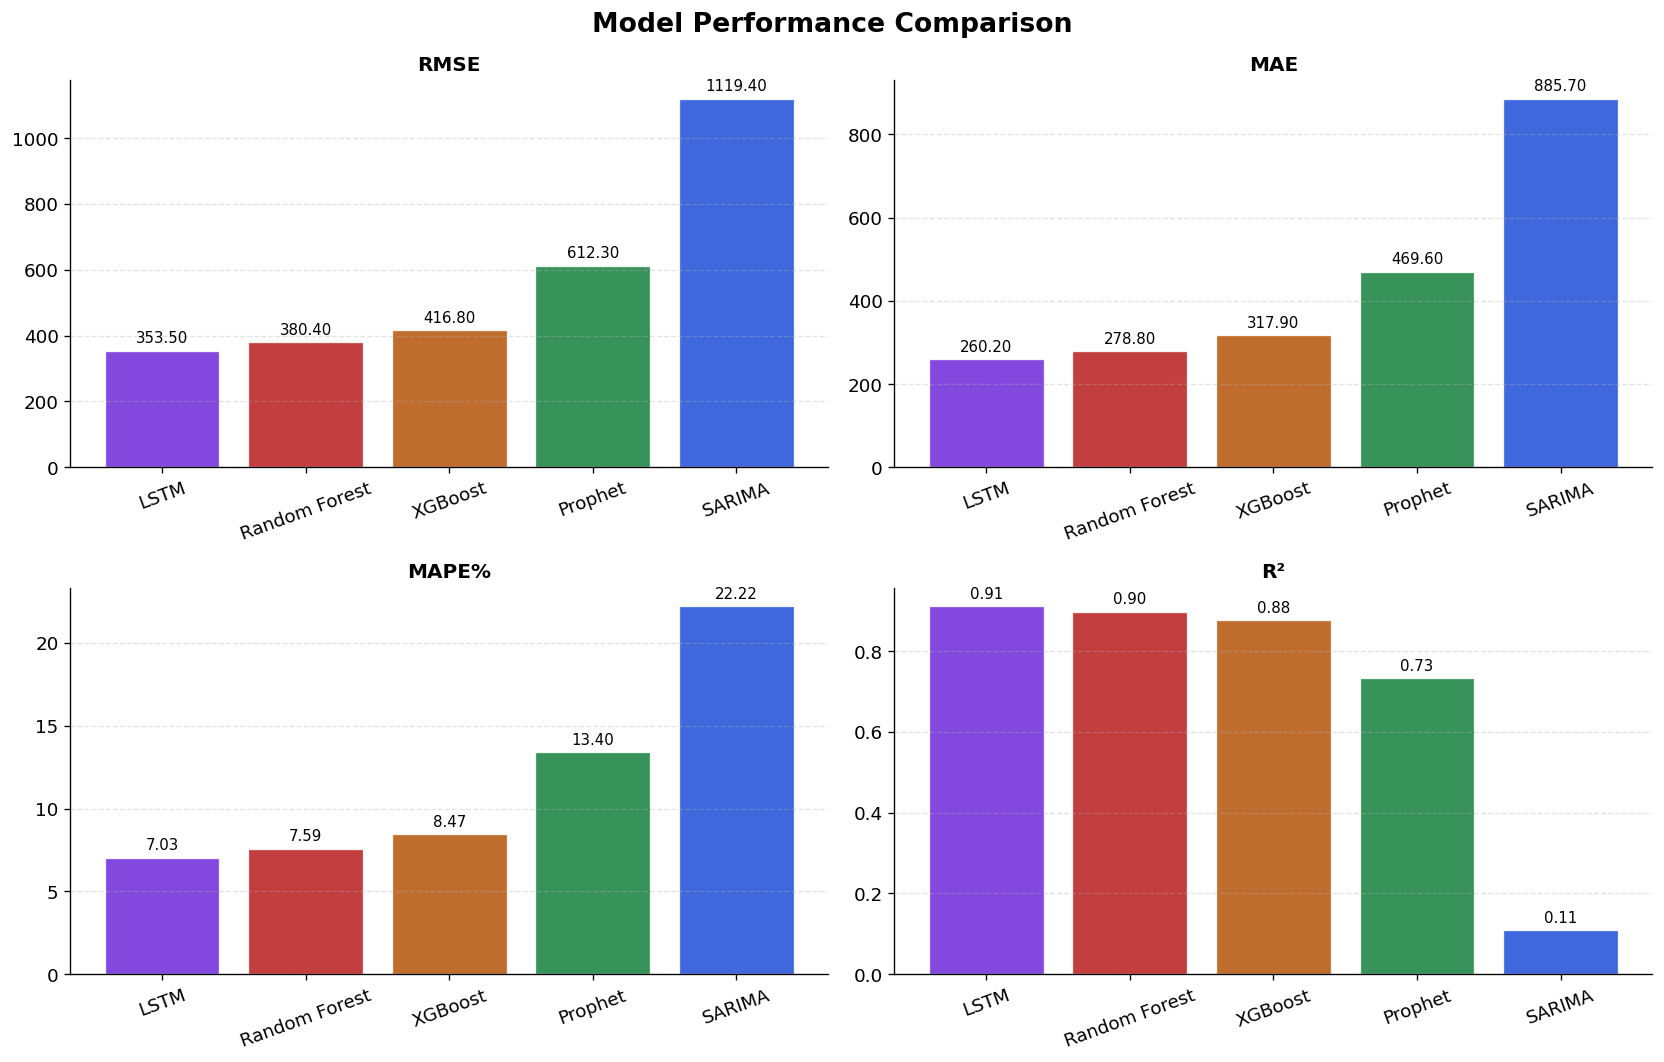

In [24]:
metrics_to_plot = ['RMSE','MAE','MAPE%','R²']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

for ax, metric in zip(axes.flat, metrics_to_plot):
    vals   = results_df[metric]
    colors = [PALETTE[LABELS.index(m)] if m in LABELS else '#94A3B8' for m in vals.index]
    bars   = ax.bar(vals.index, vals.values, color=colors, alpha=0.85,
                    edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('plots/12.1_metric_comparison.png', bbox_inches='tight')
plt.show()

### Section 5 : Forecast vs Actual

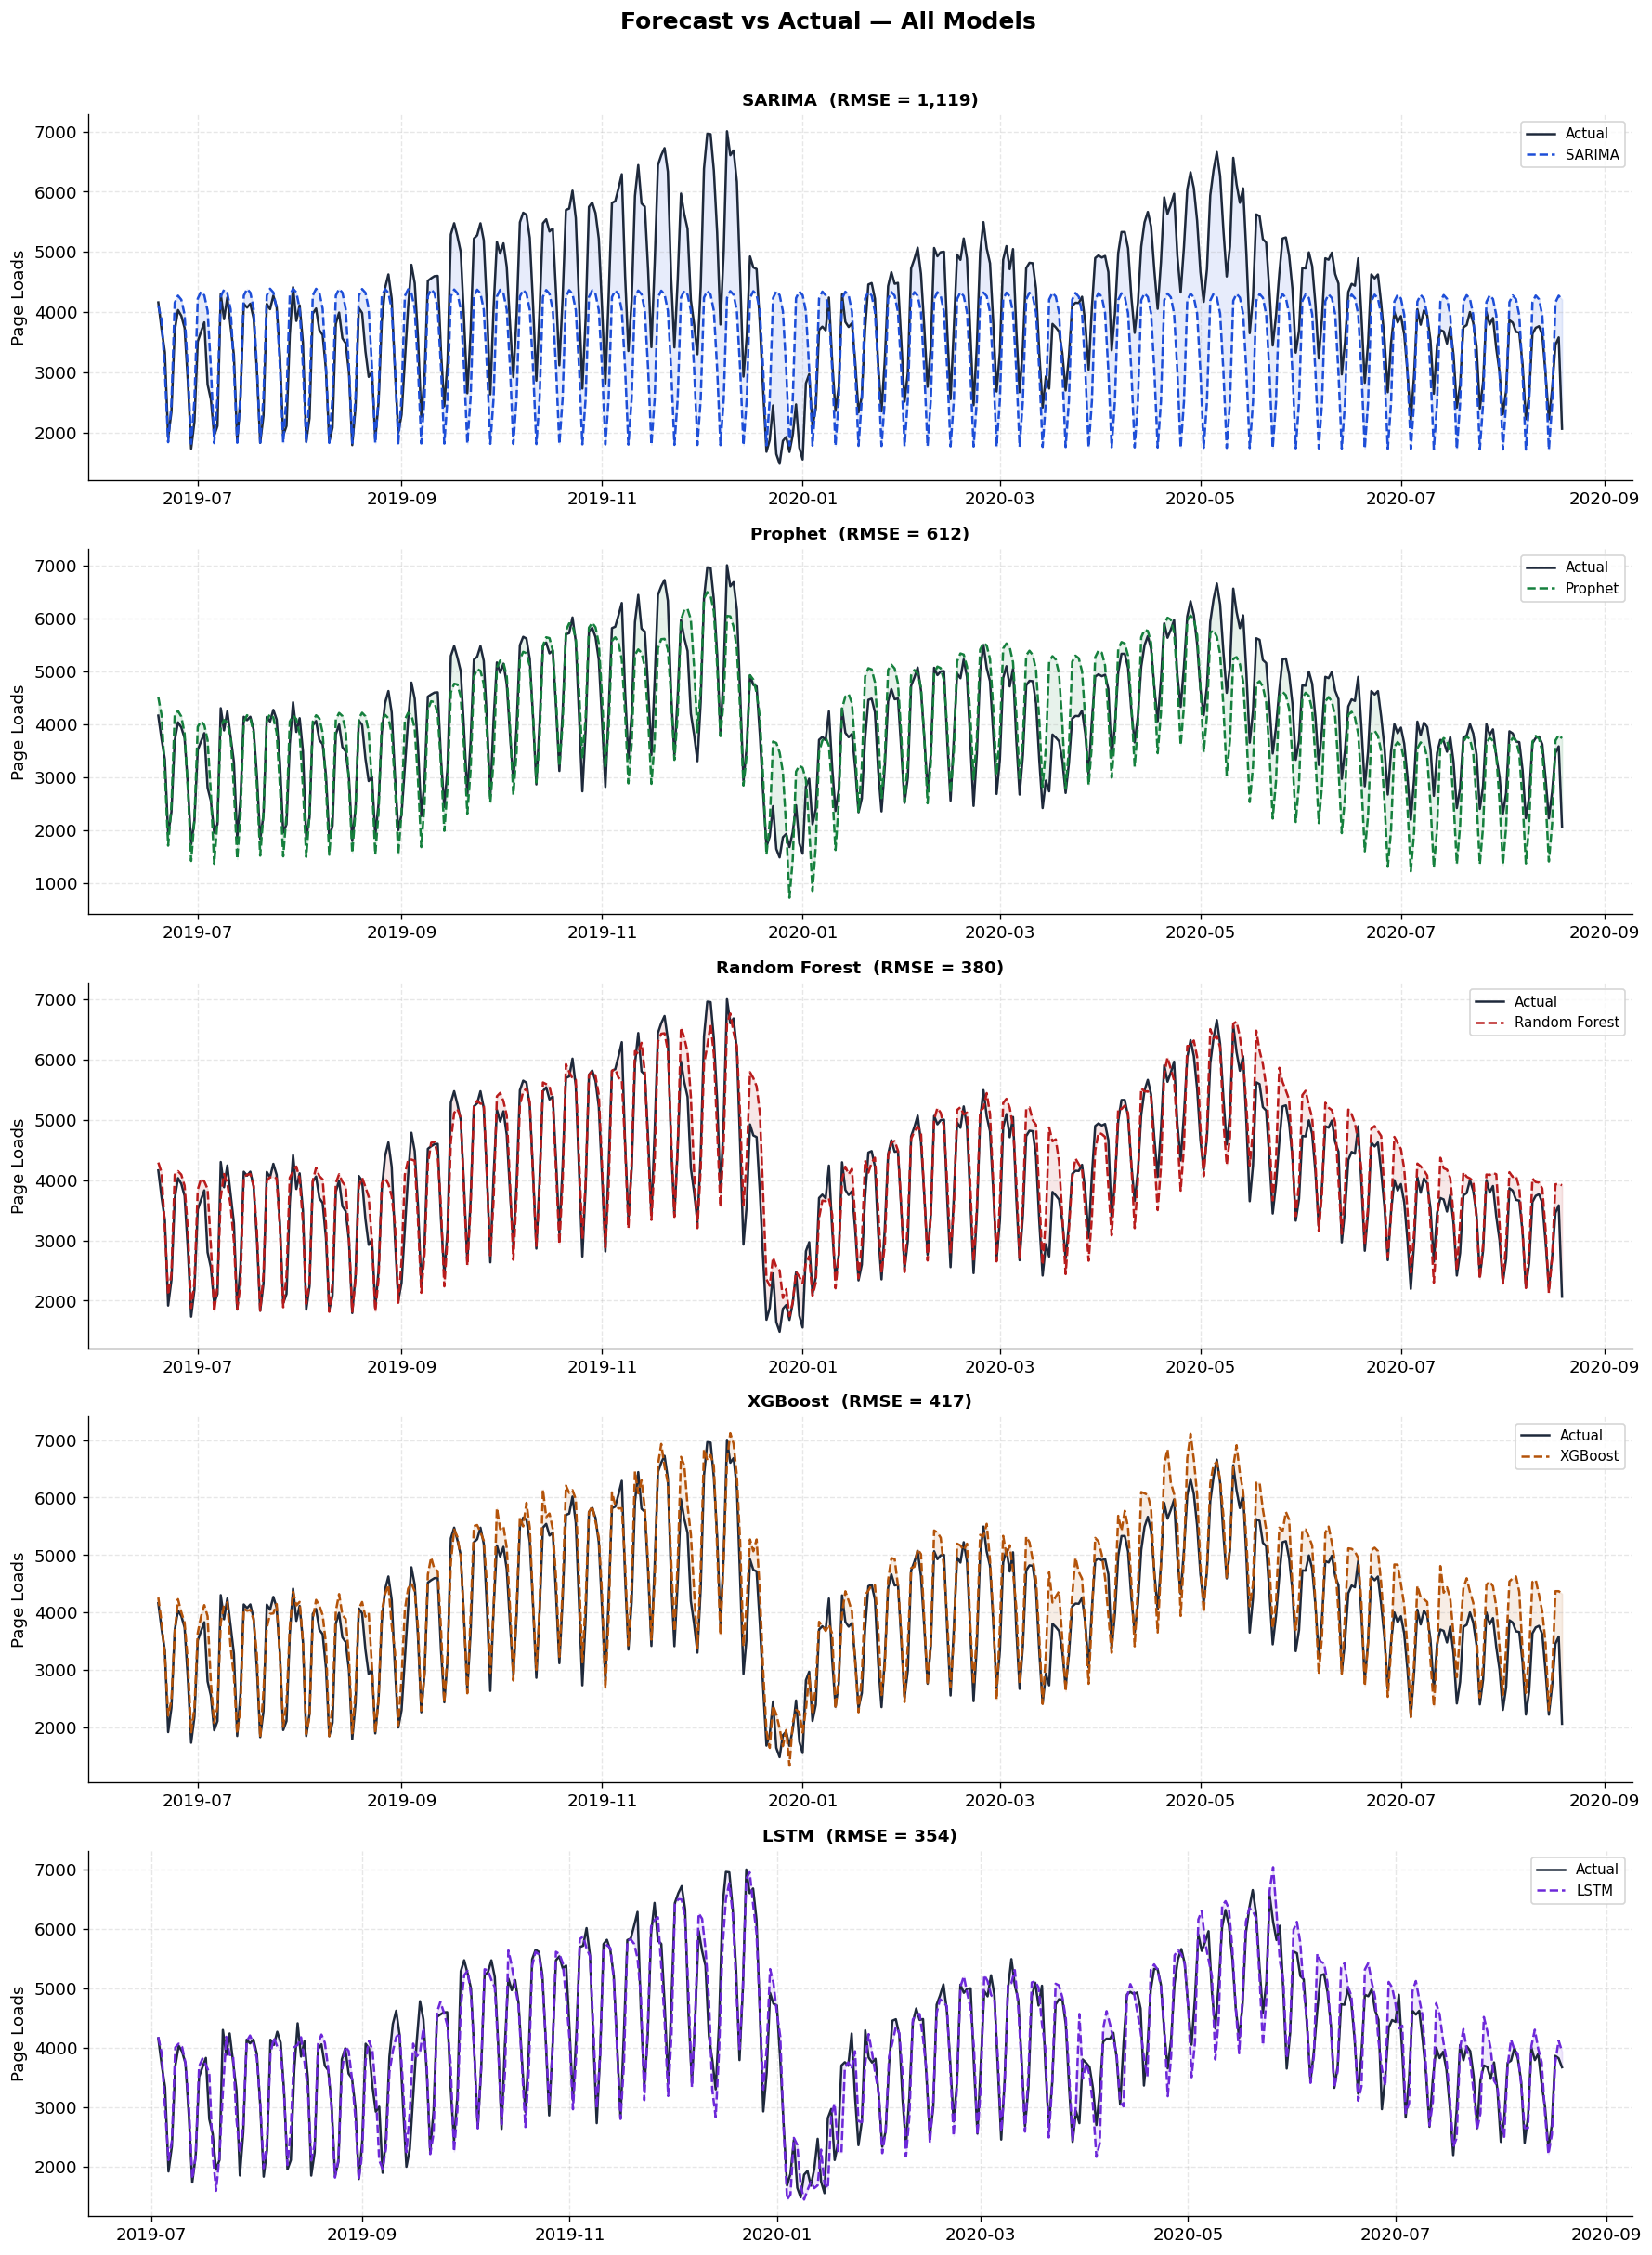

In [25]:
n_models = len(preds)
fig, axes = plt.subplots(n_models, 1, figsize=(15, 4*n_models), sharex=False)
if n_models == 1: axes = [axes]
fig.suptitle('Forecast vs Actual — All Models', fontsize=15, fontweight='bold', y=1.01)

for ax, (m, label) in zip(axes, zip(MODELS, LABELS)):
    if m not in preds: continue
    p = preds[m]
    ax.plot(p['Date'], p['y_true'], color='#1E293B', lw=1.5, label='Actual')
    ax.plot(p['Date'], p['y_pred'], color=M_COLOR[m], lw=1.5,
            linestyle='--', label=label)
    ax.fill_between(p['Date'], p['y_true'], p['y_pred'],
                    alpha=0.10, color=M_COLOR[m])
    rmse_val = np.sqrt(mean_squared_error(p['y_true'], p['y_pred']))
    ax.set_title(f'{label}  (RMSE = {rmse_val:,.0f})', fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylabel('Page Loads')

plt.tight_layout()
plt.savefig('plots/13.1_forecast_panels.png', bbox_inches='tight')
plt.show()

### SECTION 6 : ALL Models

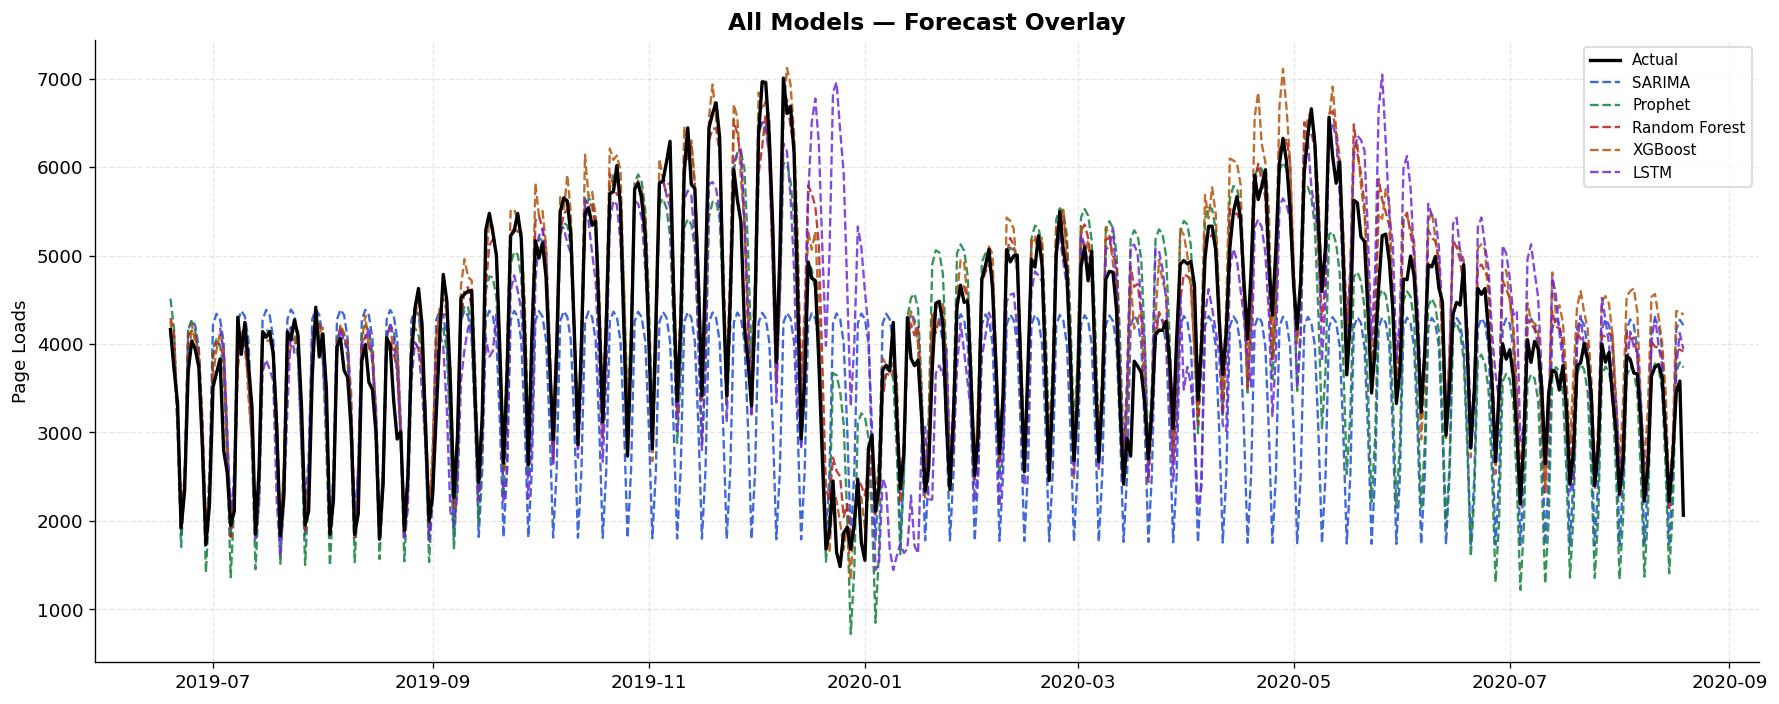

In [26]:
base_m = max(preds, key=lambda m: len(preds[m]))
base_p = preds[base_m]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(base_p['Date'], base_p['y_true'], color='black', lw=2, label='Actual', zorder=5)
for m, label in zip(MODELS, LABELS):
    if m not in preds: continue
    p = preds[m]
    ax.plot(p['Date'], p['y_pred'], color=M_COLOR[m], lw=1.4,
            linestyle='--', alpha=0.85, label=label)
ax.set_title('All Models — Forecast Overlay', fontsize=14, fontweight='bold')
ax.set_ylabel('Page Loads')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/14.1_overlay.png', bbox_inches='tight')
plt.show()

### SECtion 7 : Residual Analysis

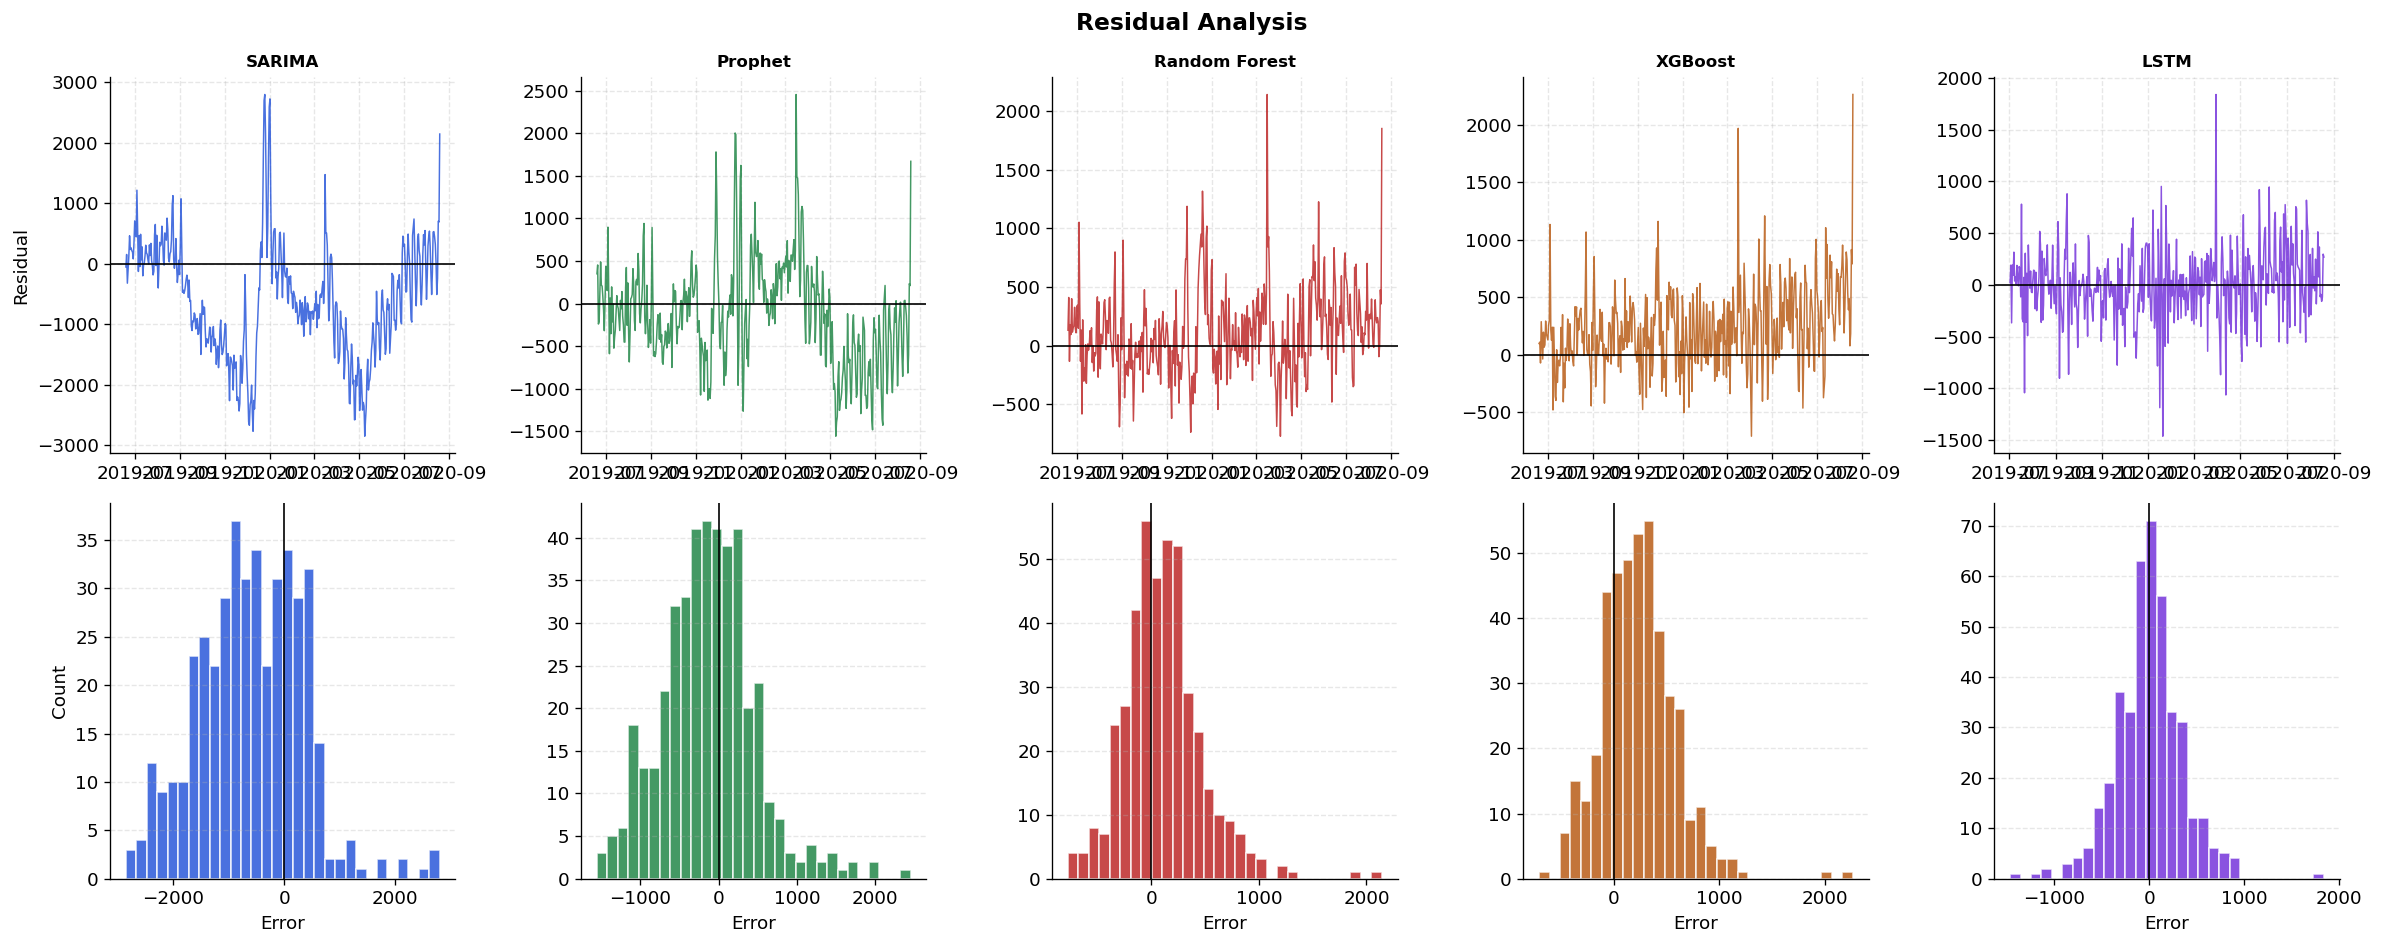

In [27]:
fig, axes = plt.subplots(2, n_models, figsize=(4*n_models, 8))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

for col, (m, label) in enumerate(zip(MODELS, LABELS)):
    if m not in preds: continue
    p         = preds[m]
    residuals = p['y_pred'].values - p['y_true'].values

    axes[0, col].plot(p['Date'], residuals, color=M_COLOR[m], lw=0.9, alpha=0.8)
    axes[0, col].axhline(0, color='black', lw=1)
    axes[0, col].set_title(label, fontsize=10, fontweight='bold')
    axes[0, col].set_ylabel('Residual' if col == 0 else '')
    axes[0, col].grid(True, linestyle='--', alpha=0.3)

    axes[1, col].hist(residuals, bins=30, color=M_COLOR[m], alpha=0.8, edgecolor='white')
    axes[1, col].axvline(0, color='black', lw=1)
    axes[1, col].set_xlabel('Error')
    axes[1, col].set_ylabel('Count' if col == 0 else '')
    axes[1, col].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/15.1_residuals.png', bbox_inches='tight')
plt.show()

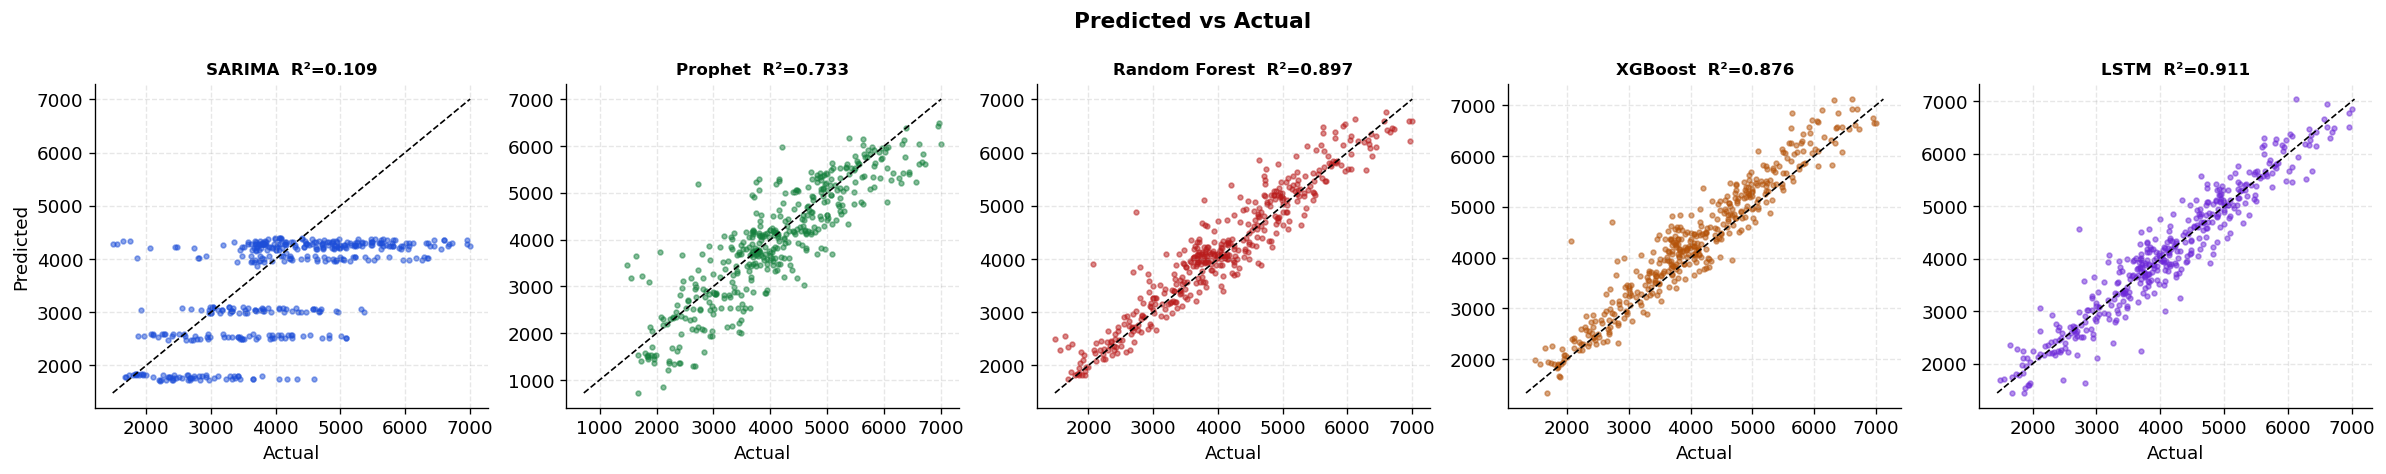

In [28]:
# Scatter: Predicted vs Actual
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
if n_models == 1: axes = [axes]
fig.suptitle('Predicted vs Actual', fontsize=13, fontweight='bold')

for ax, (m, label) in zip(axes, zip(MODELS, LABELS)):
    if m not in preds: continue
    p  = preds[m]
    ax.scatter(p['y_true'], p['y_pred'], s=8, alpha=0.5, color=M_COLOR[m])
    lo = min(p['y_true'].min(), p['y_pred'].min())
    hi = max(p['y_true'].max(), p['y_pred'].max())
    ax.plot([lo,hi],[lo,hi],'k--',lw=1)
    r2 = r2_score(p['y_true'], p['y_pred'])
    ax.set_title(f'{label}  R²={r2:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted' if ax==axes[0] else '')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/16.1_scatter.png', bbox_inches='tight')
plt.show()

### Section 8 : Error Distribution

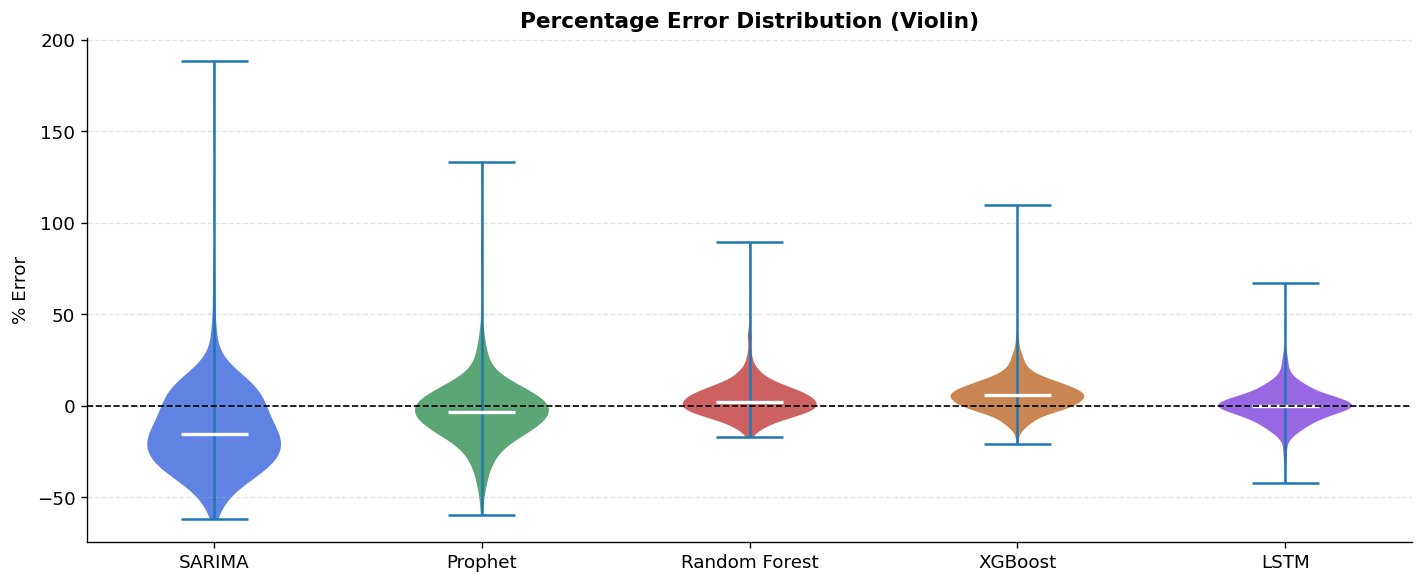

In [29]:
error_data, error_labels, error_colors = [], [], []
for m, label in zip(MODELS, LABELS):
    if m not in preds: continue
    p       = preds[m]
    pct_err = (p['y_pred'].values - p['y_true'].values) / (p['y_true'].values + 1) * 100
    error_data.append(pct_err)
    error_labels.append(label)
    error_colors.append(M_COLOR[m])

fig, ax = plt.subplots(figsize=(12, 5))
vp = ax.violinplot(error_data, positions=range(len(error_data)),
                   showmedians=True, showmeans=False)
for body, color in zip(vp['bodies'], error_colors):
    body.set_facecolor(color); body.set_alpha(0.7)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(error_labels)))
ax.set_xticklabels(error_labels)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_title('Percentage Error Distribution (Violin)', fontsize=13, fontweight='bold')
ax.set_ylabel('% Error')
ax.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('plots/17.1_error_violin.png', bbox_inches='tight')
plt.show()

### Section 9 : SHAP ANALYSIS

#### 9.1 : Compute Shap Values

In [30]:
# ── XGBoost SHAP (TreeExplainer — exact, fast) ────────────────────
if 'XGBoost' in models_loaded:
    xgb_model = models_loaded['XGBoost']
    explainer_xgb  = shap.TreeExplainer(xgb_model)
    shap_vals_xgb  = explainer_xgb(X_test)          # Explanation object
    shap_arr_xgb   = shap_vals_xgb.values           # numpy array (n_samples, n_features)
    print(f'XGBoost SHAP computed — shape: {shap_arr_xgb.shape}')
else:
    print('XGBoost model not found. Re-run NB2.')

XGBoost SHAP computed — shape: (428, 40)


In [31]:
# ── Random Forest SHAP ────────────────────────────────────────────
if 'Random Forest' in models_loaded:
    rf_model = models_loaded['Random Forest']
    # Use a background sample for speed (100 rows)
    bg_sample      = shap.sample(X_train, 100, random_state=42)
    explainer_rf   = shap.TreeExplainer(rf_model, bg_sample)
    shap_vals_rf   = explainer_rf(X_test)
    shap_arr_rf    = shap_vals_rf.values
    print(f'Random Forest SHAP computed — shape: {shap_arr_rf.shape}')
else:
    print('Random Forest model not found. Re-run NB2.')

 99%|===================| 425/428 [01:35<00:00]        

Random Forest SHAP computed — shape: (428, 40)


#### 9.2 BeeSwarm(Summary)